<a href="https://colab.research.google.com/github/zaffaazz/DKA/blob/main/103112400212_Zaffa_Azzahra_Modul10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
print("Zaffa Azzahra")  # Tuliskan nama lengkap Anda
print("103112400212")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/15BaKAdff4rM_chVwR9faJ1oT6v7GxVxM#scrollTo=nUxPUvduWpAK") # Link collab Guided
print("https://colab.research.google.com/drive/1t2VilfHFzrRognyPZsXlM5jYx0eMHGJw#scrollTo=3z7z7b-pWRDb") # Link collab Jurnal

Zaffa Azzahra
103112400212
IF-12-06
https://colab.research.google.com/drive/15BaKAdff4rM_chVwR9faJ1oT6v7GxVxM#scrollTo=nUxPUvduWpAK
https://colab.research.google.com/drive/1t2VilfHFzrRognyPZsXlM5jYx0eMHGJw#scrollTo=3z7z7b-pWRDb


In [144]:
import networkx as nx  # Library untuk membuat graf
import matplotlib.pyplot as plt # Library bantuan untuk mencetak visualisasi graf

library untuk menenambahkan sebuah graph dan visualisasi graph

In [145]:
def show_graph(G, pos=None, title='', labels={}):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(14,10), dpi=120)

    # gambar node & edge
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color='white',
        edgecolors='black',
        node_size=900,
        width=1.5
    )


    pos_labels = {k: (v[0], v[1]+0.15) for k, v in pos.items()}
    nx.draw_networkx_labels(
        G,
        pos_labels,
        labels=labels if labels else None,
        font_size=11,
        font_weight='bold',
        font_color='black'
    )

    # label edge (jarak)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9,
        bbox=dict(facecolor='white', edgecolor='none', pad=1)
    )

    plt.margins(0.2)
    plt.title(title, fontsize=12)
    plt.axis('off')
    plt.show()

Kode diatas berfungsi sebagai mengatur bagaimana graph akan divisualisasikan baik berupa warna, ukuran, dll.

In [146]:
pos = {
    'Jakarta':    (0,   0),
    'Bandung':    (1,  -2),
    'Cirebon':    (3,   0),
    'Semarang':   (5,   0),
    'Yogyakarta': (4,  -2),
    'Surakarta':  (6,  -1),
    'Surabaya':   (8,   0),
    'Malang':     (8,  -2),
}


Untuk menentukan posisi setiap node pada graph.

In [147]:
jawa = nx.Graph()

inisialisasi graph kosong tidak berarah

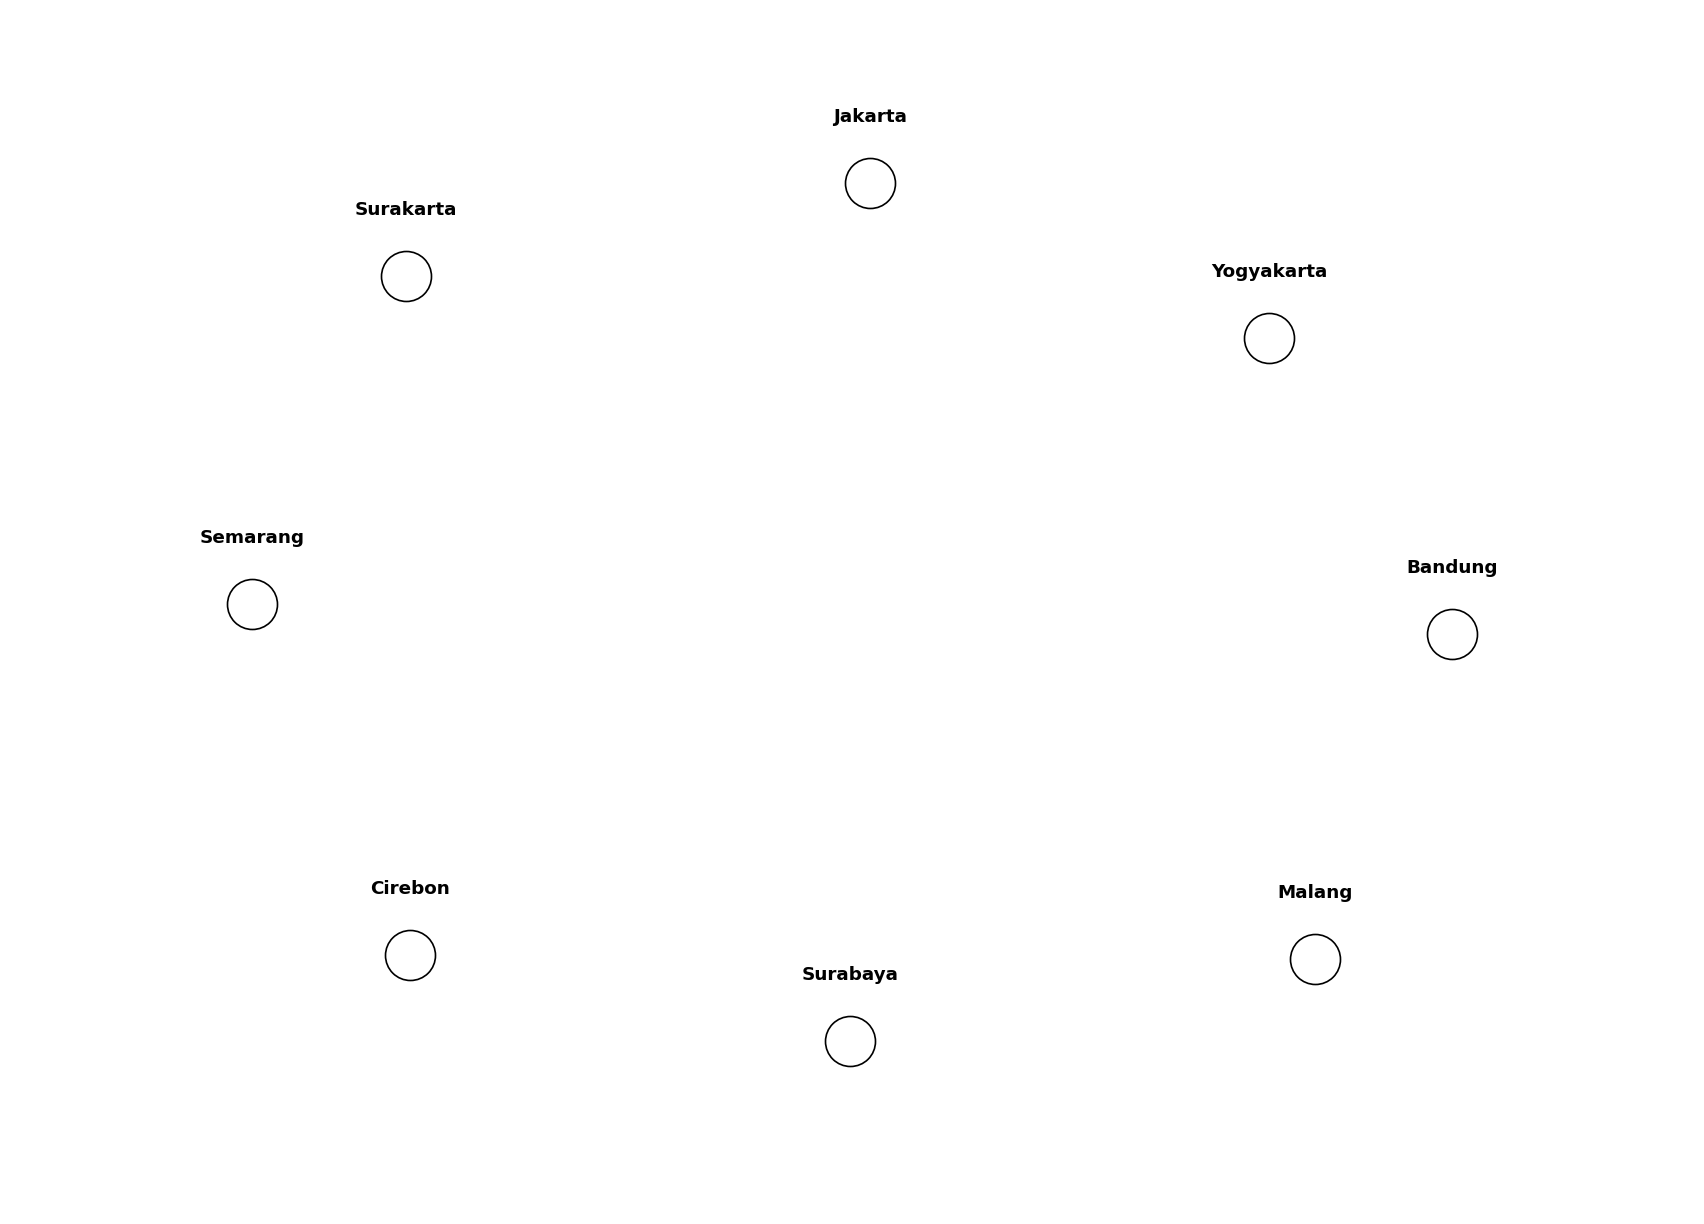

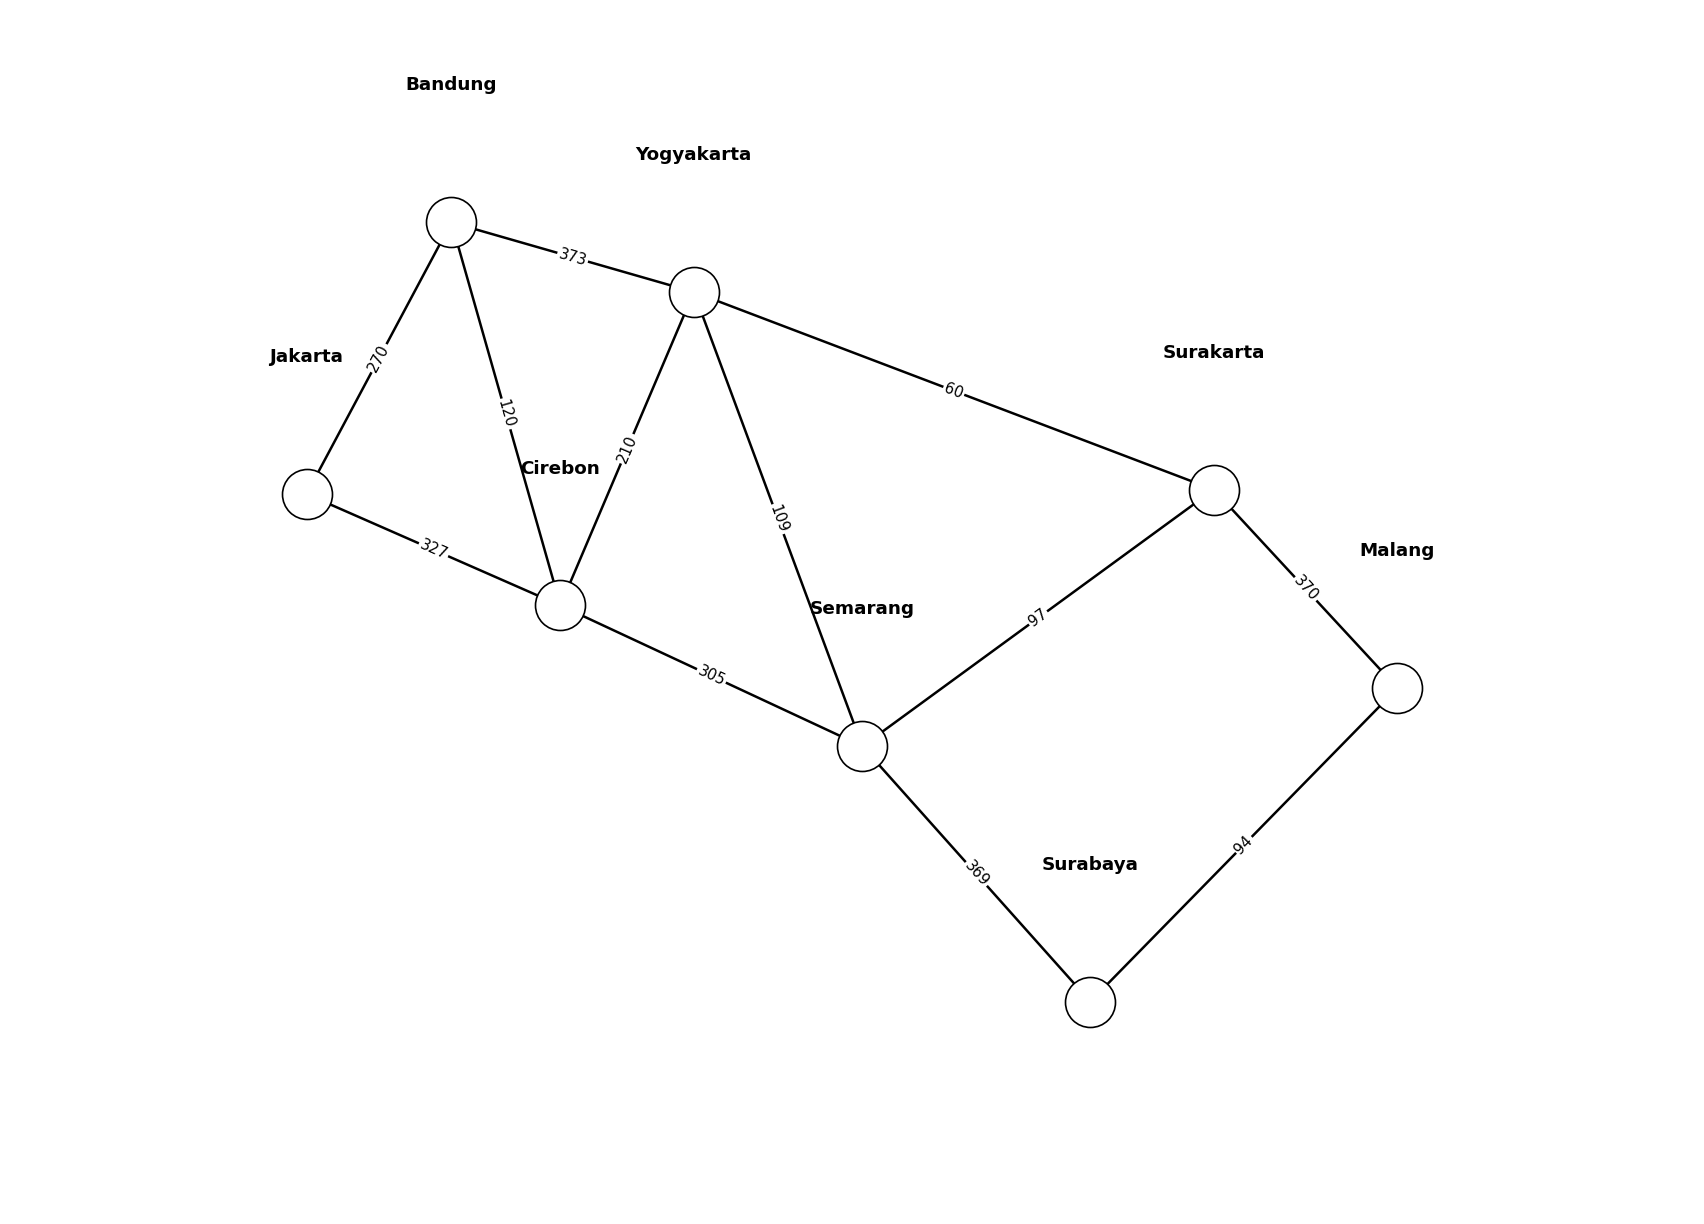

In [148]:
# daftar node (kota)
nodes = [
    'Jakarta', 'Bandung', 'Cirebon',
    'Semarang', 'Yogyakarta',
    'Surakarta', 'Malang', 'Surabaya'
]

jawa.add_nodes_from(nodes)

show_graph(jawa)

# daftar edge
edges = [
    ('Jakarta', 'Cirebon', 327),
    ('Jakarta', 'Bandung', 270),
    ('Bandung', 'Cirebon', 120),
    ('Bandung', 'Yogyakarta', 373),
    ('Cirebon', 'Semarang', 305),
    ('Cirebon', 'Yogyakarta', 210),
    ('Semarang', 'Yogyakarta', 109),
    ('Semarang', 'Surakarta', 97),
    ('Yogyakarta', 'Surakarta', 60),
    ('Semarang', 'Surabaya', 369),
    ('Surakarta', 'Malang', 370),
    ('Surabaya', 'Malang', 94)
]

jawa.add_weighted_edges_from(edges)

show_graph(jawa)

Kode diatas menjelaskan tentang menambahkan pasangan setiap node beserta weightnya pada graph dan menamapilkan graph yang sudah dibuat dengen node yang sudah ditentukan sebelumnya.

In [118]:
import math
# Input berupa 2 tupple koordinat
def jarakEuclidean(a,b):
    return math.sqrt((b[0] - a[0])**2 + (b[1] - a[1])**2) # hitung dengan menggunakan rumus jarak euclidean

Fungsi di atas menghitung jarak antara dua titik koordinat (x1, y1) dan (x2, y2)

In [119]:
import heapq

def gbfs(graph, start, goal):
    open_set = [(jarakEuclidean(pos[start], pos[goal]), start)]
    came_from = {start: None}

    while open_set:
        _, current = heapq.heappop(open_set)
        if current == goal:
            break
        for neighbor in graph.neighbors(current):
            if neighbor not in came_from:
                came_from[neighbor] = current
                h = jarakEuclidean(pos[neighbor], pos[goal])
                heapq.heappush(open_set, (h, neighbor))

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    path.reverse()
    return path

Kode di atas menjelaskan tentang pencarian solusi menggunakan algoritma Greedy Best First Search (GBFS) dimana pemilihan node berdasarkan nilai heuristic yang jaraknya terdekat ke node tujuan. Pada bagian open_set digunakan untuk menyimpan node yang akan dikunjungi, dimana node dengan nilai heuristic paling kecil akan diproses terlebih dahulu, Kemudian node dengan jarak terdekat diambil menggunakan heapq dan heappop dijadikan untuk node saat ini. Selanjutnya, semua tetangga dari node saat ini diperiksa, dan node yang belum dikunjungi akan disimpan asalnya untuk membentuk jalur dari node awal ke node tujuan.

In [120]:
def heuristic(node, goal):
    return jarakEuclidean(pos[node], pos[goal])

fungsi heuristic yang digunakan untuk menghitung jarak dari suatu node ke node tujuan.

In [121]:
for kota in nodes:
    if kota in pos and 'Malang' in pos:
        h = heuristic(kota, 'Malang')
        print(kota, ":", h)
    else:
        print(kota, "tidak ada di pos")

Jakarta : 8.246211251235321
Bandung : 7.0
Cirebon : 5.385164807134504
Semarang : 3.605551275463989
Yogyakarta : 4.0
Surakarta : 2.23606797749979
Malang : 0.0
Surabaya : 2.0


Kode di atas menampilkan nilai heuristic setiap kota.

In [122]:
jawa_unweighted = nx.Graph()
jawa_unweighted.add_nodes_from(jawa.nodes)
jawa_unweighted.add_edges_from(jawa.edges)

Kode di atas digunakan untuk inisalisasi graph baru tidak berbobot dan tanpa menambahkan bobot pada graph.

In [123]:
# Input dari user
start_node = input("Masukkan kota awal: ")
end_node   = input("Masukkan kota tujuan: ")

# Validasi input
if start_node not in nodes or end_node not in nodes:
    print("Kota tidak ditemukan! Pilih dari:", nodes)
else:
    path = gbfs(jawa_unweighted, start_node, end_node)
    total = sum(jawa[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

print("Rute Terpendek:")
for i in range(len(path) - 1):
    print(f"{path[i]} -> ", end="")
print(path[-1])

print("\nTotal Jarak:", total, "km")

Masukkan kota awal: Bandung
Masukkan kota tujuan: Malang
Rute Terpendek:
Bandung -> Yogyakarta -> Surakarta -> Malang

Total Jarak: 803 km


Kode di atas menjelaskan tentang pencarian solusi menggunakan algoritma Greedy Best First Search (GBFS). Jika input valid, maka proses pencarian jalur dilakukan menggunakan fungsi gbfs(jawa_unweighted, start_node, end_node) untuk mendapatkan rute dari kota awal ke kota tujuan. Selanjutnya, total jarak dihitung menggunakan sum(jawa[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) yang menjumlahkan bobot setiap edge yang dilalui dan hasil akhirnya akan menampilkan jalur yang dilalui serta total jarak yang ditempuh.

In [149]:
import networkx as nx  # Library untuk membuat graf
import matplotlib.pyplot as plt # Library bantuan untuk mencetak visualisasi graf

library untuk menenambahkan sebuah graph dan visualisasi graph

In [150]:
def show_graph(G, pos=None, title='', labels={}):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(14,10), dpi=120)

    # gambar node & edge
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color='white',
        edgecolors='black',
        node_size=900,
        width=1.5
    )


    pos_labels = {k: (v[0], v[1]+0.15) for k, v in pos.items()}
    nx.draw_networkx_labels(
        G,
        pos_labels,
        labels=labels if labels else None,
        font_size=11,
        font_weight='bold',
        font_color='black'
    )

    # label edge (jarak)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9,
        bbox=dict(facecolor='white', edgecolor='none', pad=1)
    )

    plt.margins(0.2)
    plt.title(title, fontsize=12)
    plt.axis('off')
    plt.show()

Kode diatas berfungsi sebagai mengatur bagaimana graph akan divisualisasikan baik berupa warna, ukuran, dll.

In [154]:
pos = {
    'Arad': (1,5),
    'Zerind': (1,6),
    'Oradea': (2,7),
    'Sibiu': (3,5),
    'Timisoara': (1,3),
    'Lugoj': (2,2),
    'Mehadia': (2,1),
    'Drobeta': (2,0),
    'Craiova': (3,0),
    'Rimnicu Vilcea': (4,3),
    'Fagaras': (5,5),
    'Pitesti': (5,2),
    'Bucharest': (6,1),
    'Giurgiu': (6,0),
    'Urziceni': (7,2),
    'Hirsova': (8,2),
    'Eforie': (9,1),
    'Vaslui': (8,4),
    'Iasi': (8,6),
    'Neamt': (7,7),
}

Untuk menentukan posisi setiap node pada graph.

In [152]:
eropa = nx.Graph()

inisialisasi graph kosong tidak berarah

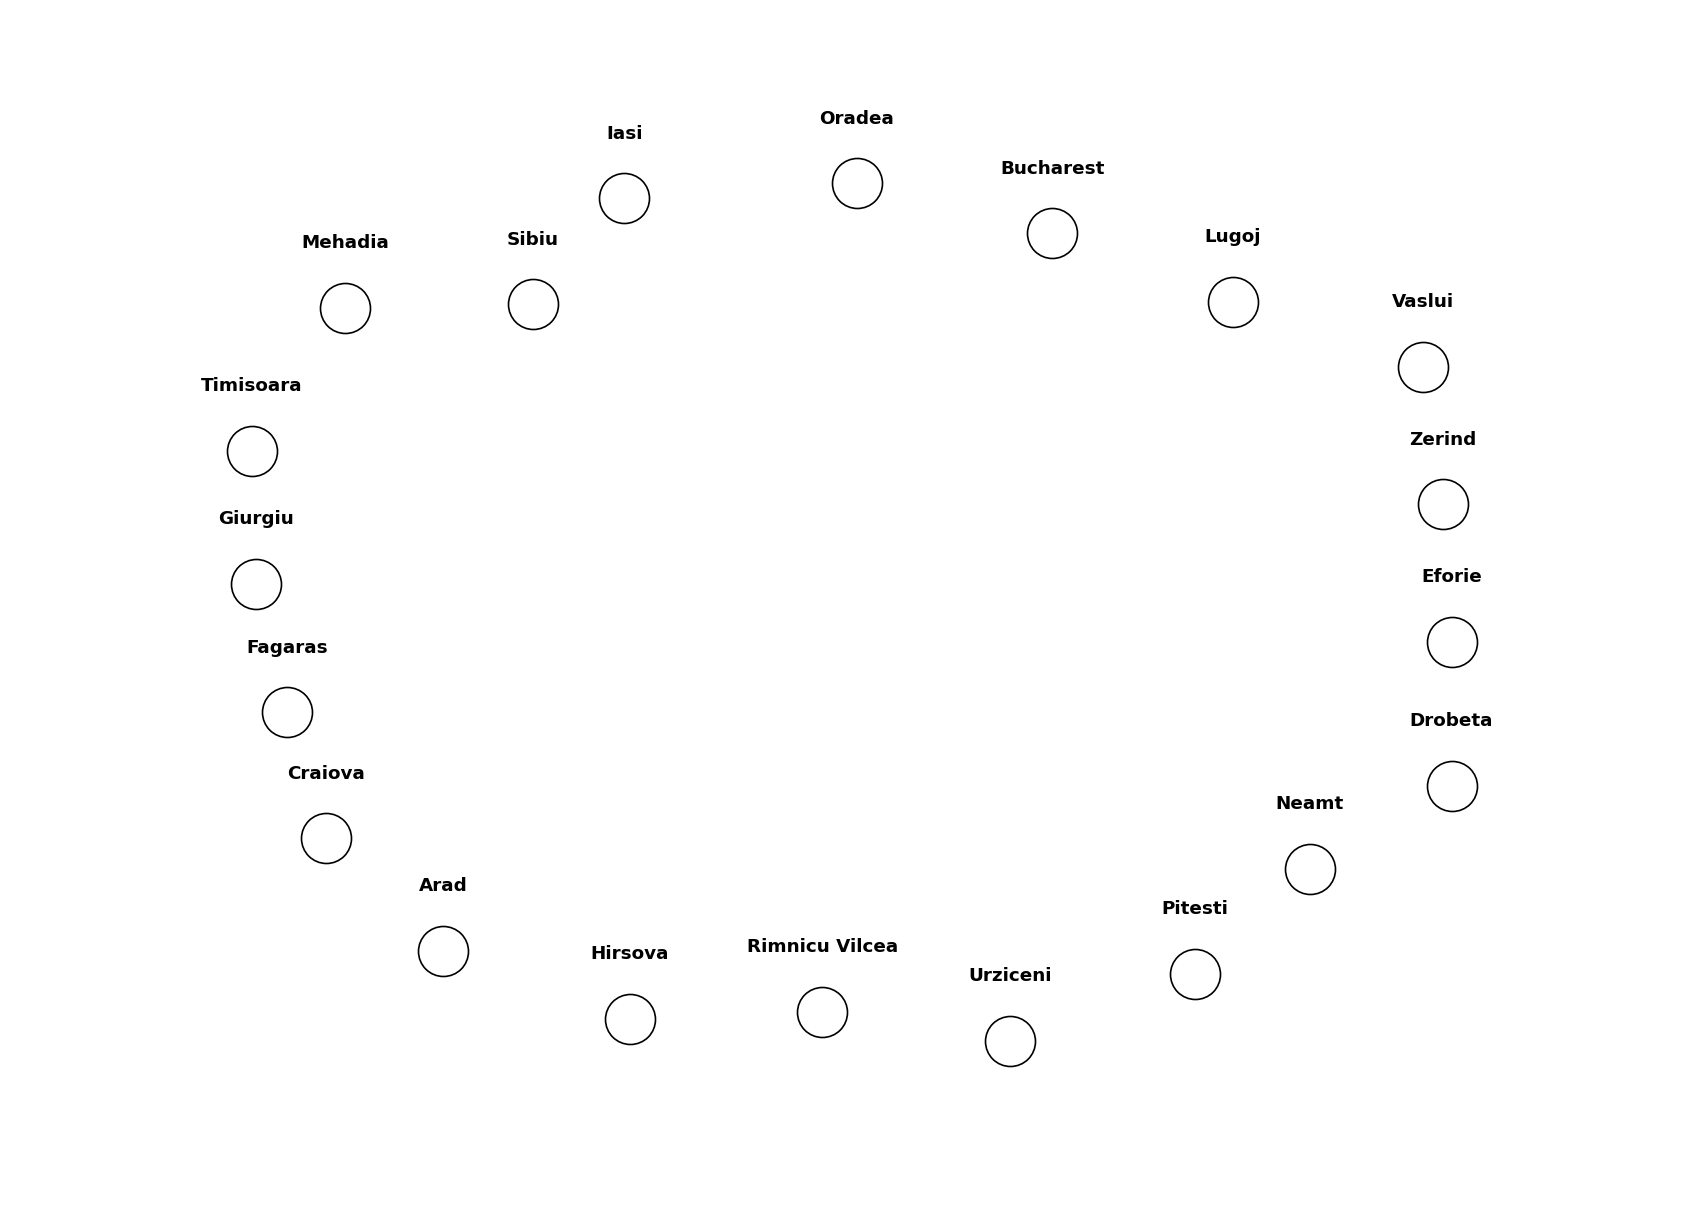

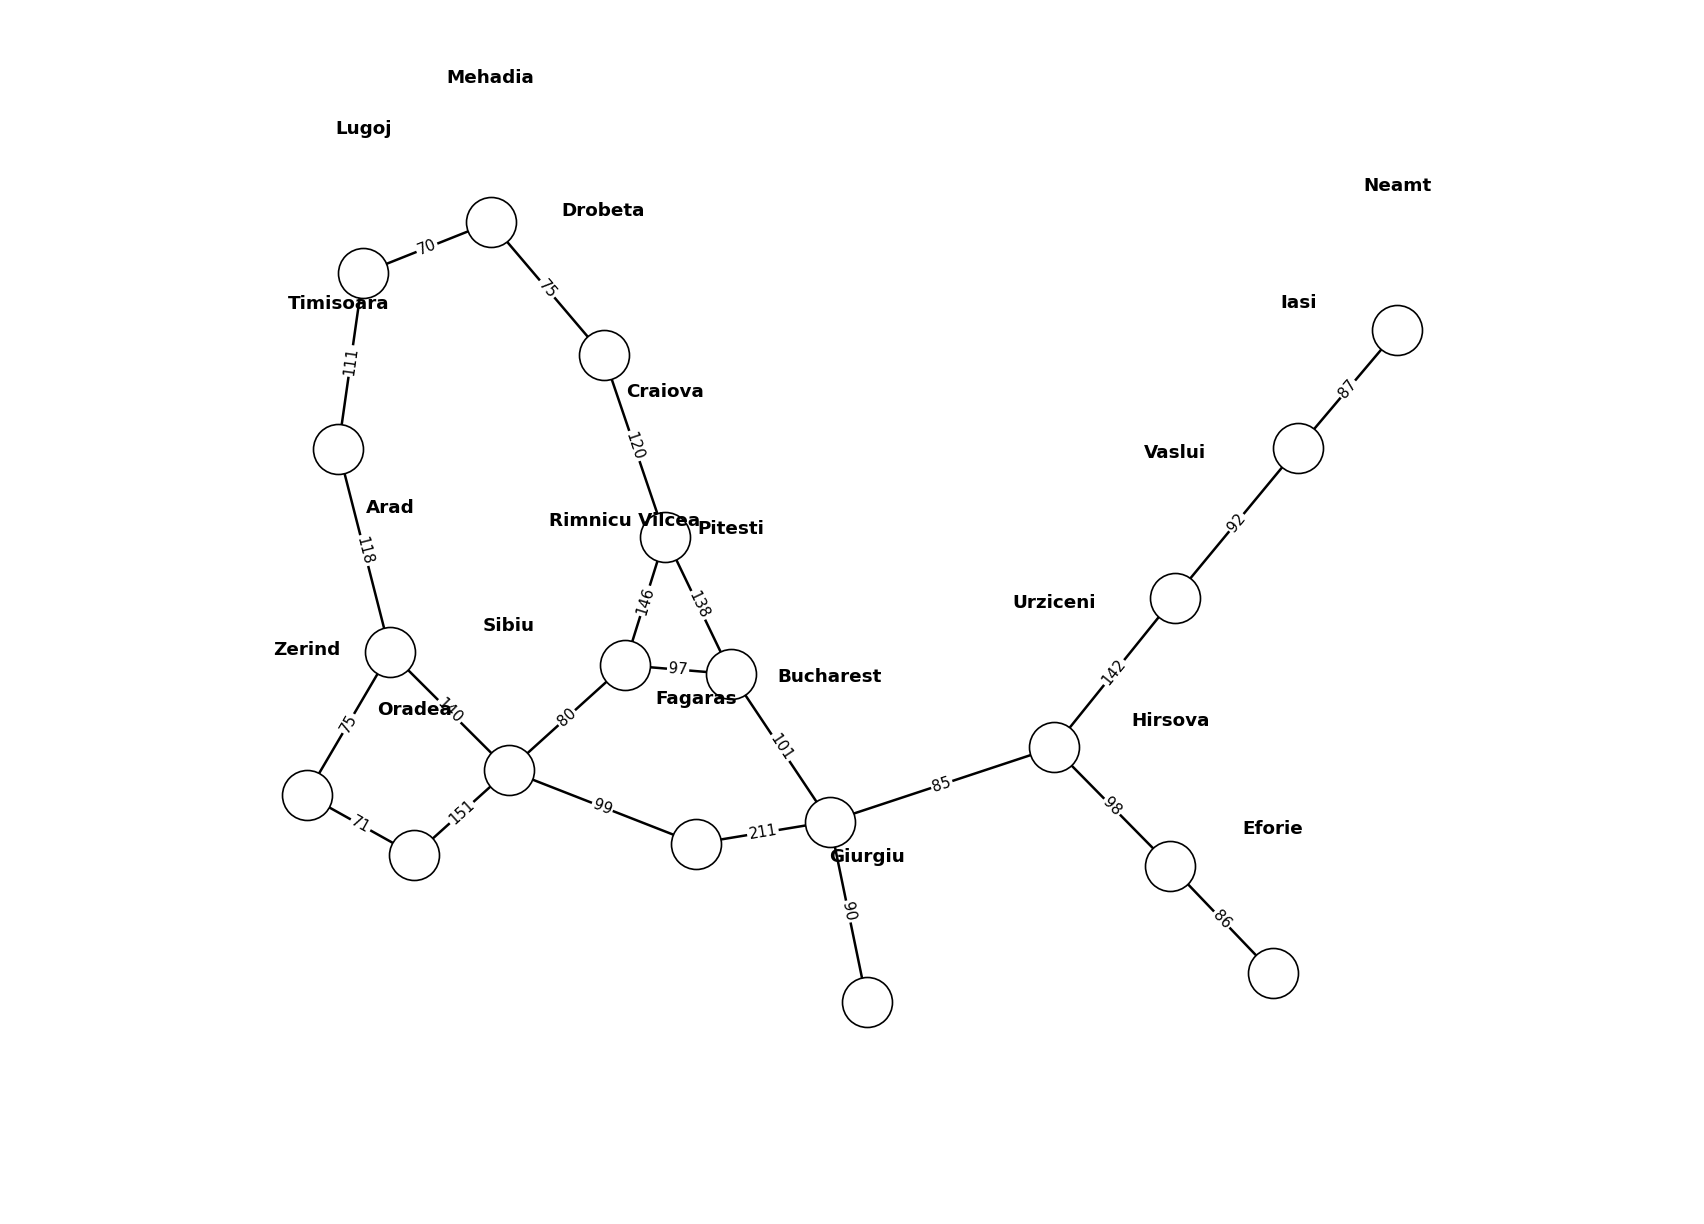

In [153]:
# daftar node (kota)
nodes = [
    'Oradea', 'Zerind','Arad',
    'Timisoara','Lugoj','Mehadia',
    'Drobeta','Craiova','Sibiu',
    'Rimnicu Vilcea', 'Pitesti','Fagaras',
    'Bucharest', 'Giurgiu','Urziceni',
    'Neamt', 'Iasi','Vaslui',
    'Hirsova','Eforie',
]

eropa.add_nodes_from(nodes)

show_graph(eropa)

# daftar edge
edges = [
    ('Oradea',         'Zerind',         71),
    ('Oradea',         'Sibiu',         151),
    ('Zerind',         'Arad',           75),
    ('Arad',           'Sibiu',         140),
    ('Arad',           'Timisoara',     118),
    ('Timisoara',      'Lugoj',         111),
    ('Lugoj',          'Mehadia',        70),
    ('Mehadia',        'Drobeta',        75),
    ('Drobeta',        'Craiova',       120),
    ('Sibiu',          'Rimnicu Vilcea', 80),
    ('Sibiu',          'Fagaras',        99),
    ('Rimnicu Vilcea', 'Pitesti',        97),
    ('Rimnicu Vilcea', 'Craiova',       146),
    ('Pitesti',        'Craiova',       138),
    ('Pitesti',        'Bucharest',     101),
    ('Fagaras',        'Bucharest',     211),
    ('Bucharest',      'Giurgiu',        90),
    ('Bucharest',      'Urziceni',       85),
    ('Urziceni',       'Vaslui',        142),
    ('Urziceni',       'Hirsova',        98),
    ('Neamt',          'Iasi',           87),
    ('Iasi',           'Vaslui',         92),
    ('Hirsova',        'Eforie',         86),
]

eropa.add_weighted_edges_from(edges)

show_graph(eropa)

Kode diatas menjelaskan tentang menambahkan pasangan setiap node beserta weightnya pada graph dan menamapilkan graph yang sudah dibuat dengen node yang sudah ditentukan sebelumnya.

Kode diatas berfungsi sebagai mengatur bagaimana graph akan divisualisasikan baik berupa warna, ukuran, dll.

In [129]:
import math
# Input berupa 2 tupple koordinat
def jarakEuclidean(a,b):
    return math.sqrt((b[0] - a[0])**2 + (b[1] - a[1])**2) # hitung dengan menggunakan rumus jarak euclidean

Fungsi di atas menghitung jarak antara dua titik koordinat (x1, y1) dan (x2, y2)

In [130]:
def heuristic_eropa(node, goal):
    return jarakEuclidean(pos[node], pos[goal])

fungsi heuristic yang digunakan untuk menghitung jarak dari suatu node ke node tujuan.

In [155]:
for kota in nodes:
    if kota in pos and 'Bucharest' in pos:
        h = heuristic(kota, 'Bucharest')
        print(kota, ":", h)
    else:
        print(kota, "tidak ada di pos")

Oradea : 7.211102550927978
Zerind : 7.0710678118654755
Arad : 6.4031242374328485
Timisoara : 5.385164807134504
Lugoj : 4.123105625617661
Mehadia : 4.0
Drobeta : 4.123105625617661
Craiova : 3.1622776601683795
Sibiu : 5.0
Rimnicu Vilcea : 2.8284271247461903
Pitesti : 1.4142135623730951
Fagaras : 4.123105625617661
Bucharest : 0.0
Giurgiu : 1.0
Urziceni : 1.4142135623730951
Neamt : 6.082762530298219
Iasi : 5.385164807134504
Vaslui : 3.605551275463989
Hirsova : 2.23606797749979
Eforie : 3.0


Kode di atas menampilkan nilai heuristic setiap kota.

In [132]:
eropa_unweighted = nx.Graph()
eropa_unweighted.add_nodes_from(eropa.nodes)
eropa_unweighted.add_edges_from(eropa.edges)

Kode di atas digunakan untuk inisalisasi graph baru tidak berbobot dan tanpa menambahkan bobot pada graph.

In [133]:
# Input dari user
start_node = input("Masukkan kota awal: ")
end_node   = input("Masukkan kota tujuan: ")

# Validasi input
if start_node not in nodes or end_node not in nodes:
    print("Kota tidak ditemukan! Pilih dari:", nodes)
else:
    path = gbfs(eropa_unweighted, start_node, end_node)
    total = sum(eropa[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

print("Rute Terpendek:")
for i in range(len(path) - 1):
    print(f"{path[i]} -> ", end="")
print(path[-1])

print("\nTotal Jarak:", total, "km")

Masukkan kota awal: Arad
Masukkan kota tujuan: Bucharest
Rute Terpendek:
Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest

Total Jarak: 418 km


Kode di atas menjelaskan tentang pencarian solusi menggunakan algoritma Greedy Best First Search (GBFS). Jika input valid, maka proses pencarian jalur dilakukan menggunakan fungsi gbfs(jawa_unweighted, start_node, end_node) untuk mendapatkan rute dari kota awal ke kota tujuan. Selanjutnya, total jarak dihitung menggunakan sum(eropa[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) yang menjumlahkan bobot setiap edge yang dilalui dan hasil akhirnya akan menampilkan jalur yang dilalui serta total jarak yang ditempuh.